### Loading and preprocessing energy data
### Training XGBoost Outage Detection Model

XGBoost Confusion Matrix:
 [[10023     1]
 [   10   486]]

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10024
           1       1.00      0.98      0.99       496

    accuracy                           1.00     10520
   macro avg       1.00      0.99      0.99     10520
weighted avg       1.00      1.00      1.00     10520


XGBoost ROC-AUC Score: 0.9898694745513993


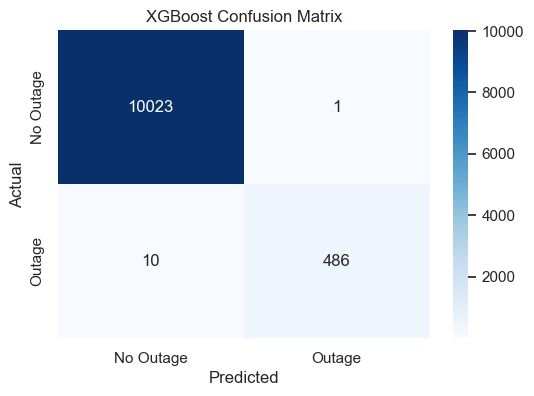

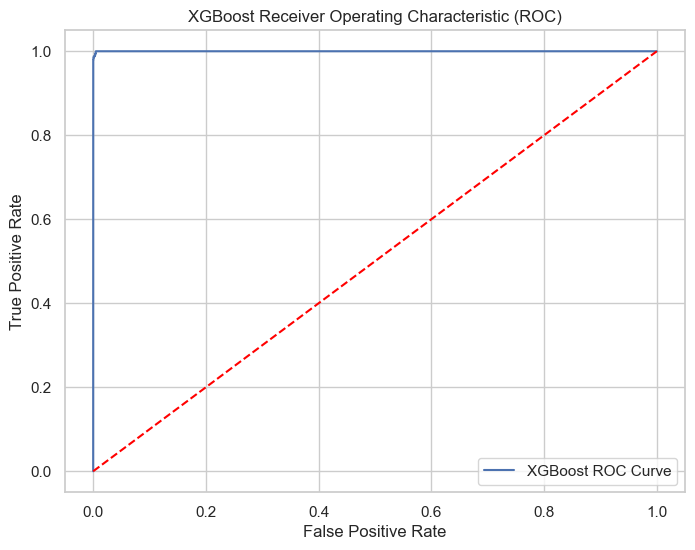

### Generating synthetic power distribution data for anomaly detection
### Visualizing anomalies in power distribution data


<Figure size 1500x1000 with 0 Axes>

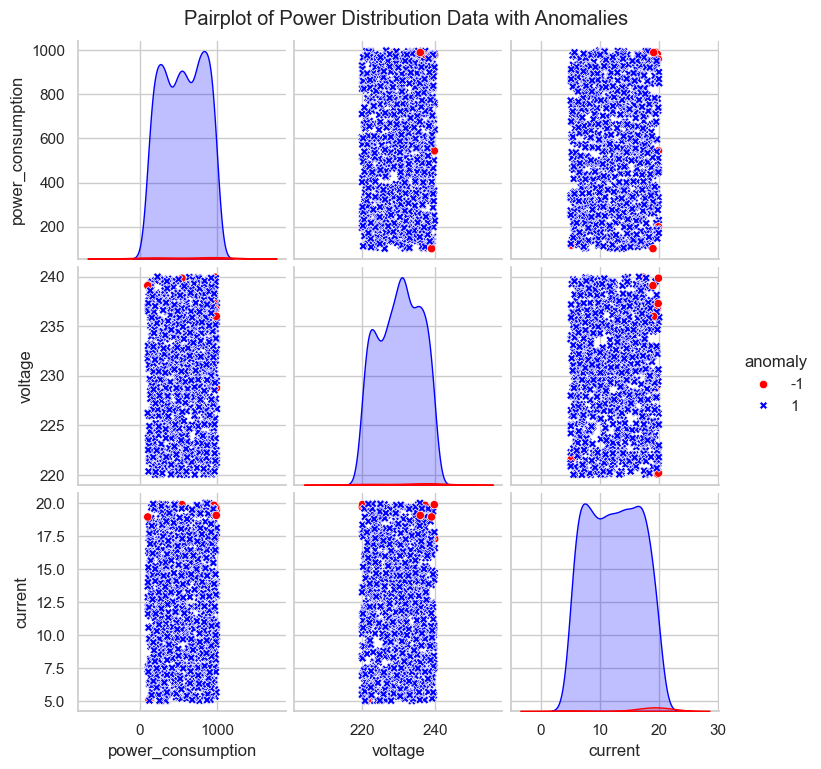

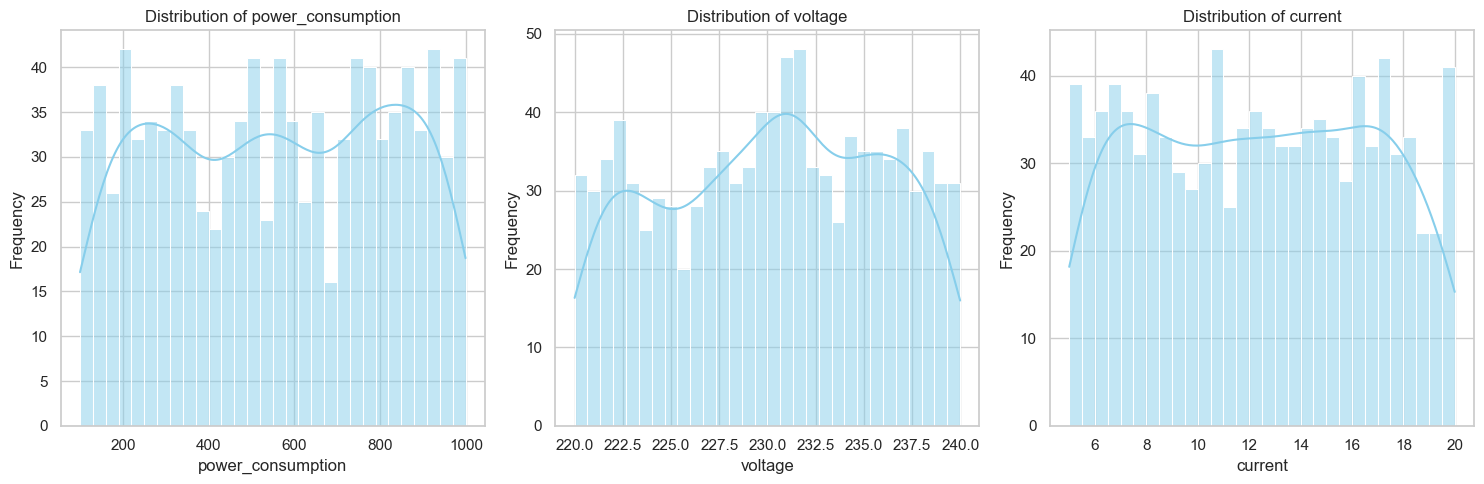

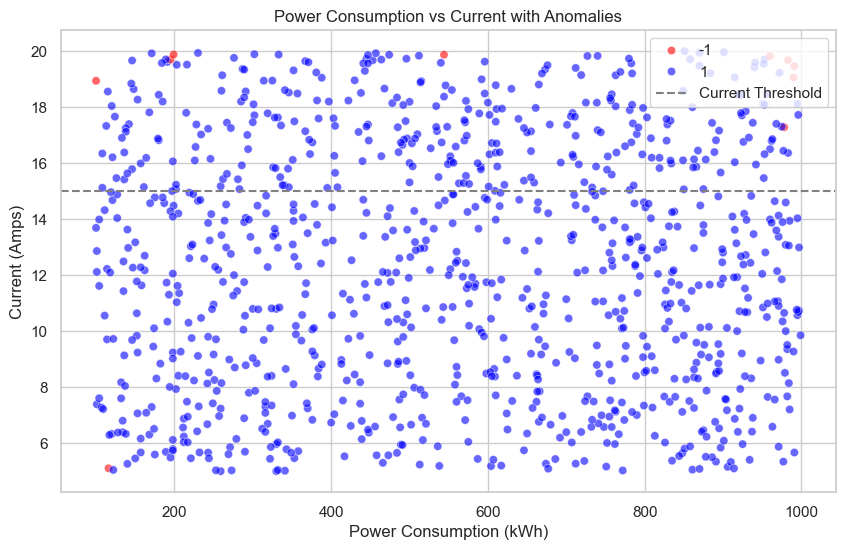

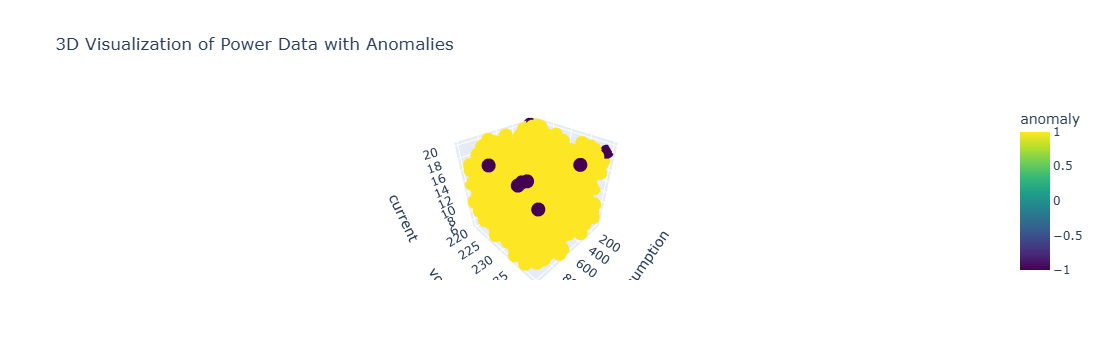

### Forecasting Energy Demand using ARIMA


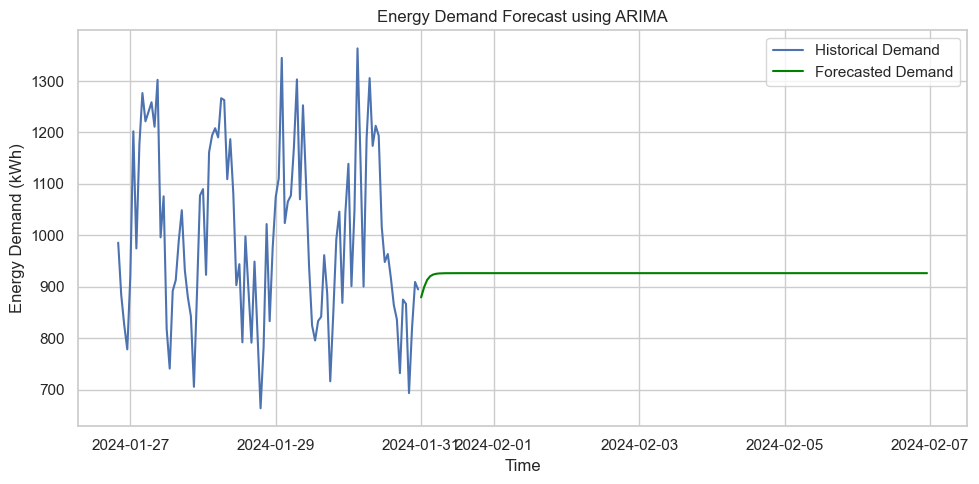

### Forecasting Renewable Energy Output using Gradient Boosting


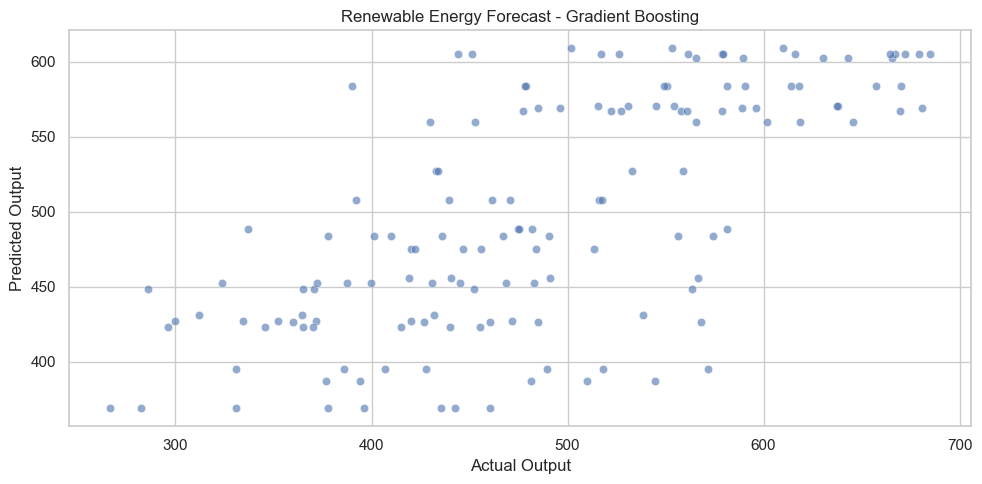

Mean Squared Error: 5460.09
### Balancing the Grid and Visualizing


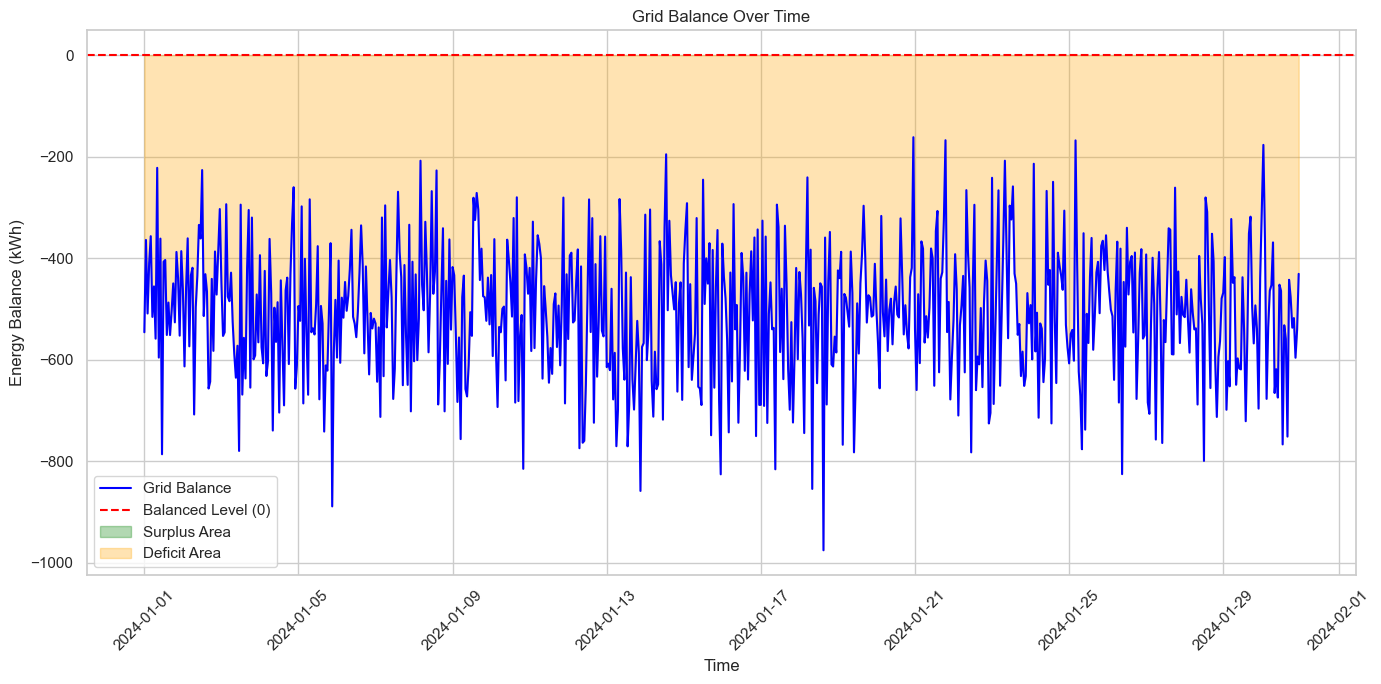

### Training LSTM Model for Load Forecasting
Epoch 1/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - loss: 833995136.0000 - val_loss: 864931264.0000
Epoch 2/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 831932416.0000 - val_loss: 862881152.0000
Epoch 3/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 832377792.0000 - val_loss: 860845632.0000
Epoch 4/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 827648064.0000 - val_loss: 858816000.0000
Epoch 5/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 824312704.0000 - val_loss: 856790976.0000
Epoch 6/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 822667328.0000 - val_loss: 854769088.0000
Epoch 7/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - loss: 822292736.0000 - val_loss: 852751296.0000
Epoch 8/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 818190656.0000 - val_loss: 850734848.0000
Epoch 9/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 819355520.0000 - val_loss: 848722240.0000
Epoch 10/10
701/701

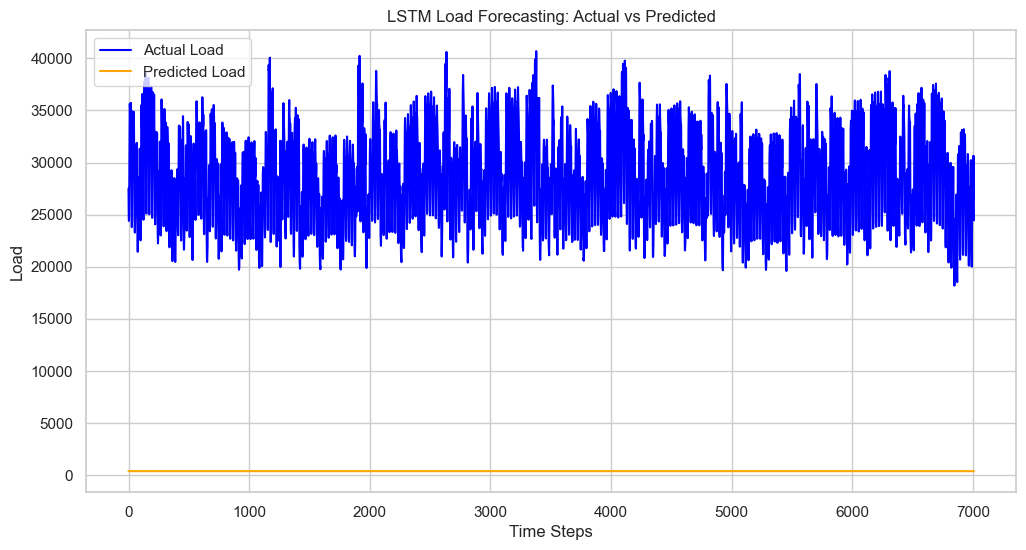

### Project Completed Successfully.


In [1]:
"""
Project Title: AI APPLICATIONS IN POWER SYSTEMS

Author: KAMBALA JAYAKRISHNA
Affiliation: SRI VENKATESWARA UNIVERSITY COLLEGE OF ENGINEERING
Date: 2025

Description:
This project implements comprehensive energy demand forecasting and power distribution anomaly detection using a suite of machine learning and statistical techniques.
The methods include XGBoost, Random Forest, LSTM, Isolation Forest, ARIMA, and Gradient Boosting Regressor applied to both real and synthetic datasets.
The objective is to provide accurate forecasting and identify anomalies such as potential power theft to enhance energy management systems.

References:
- IEEE Standards Association related documents on power system forecasting and anomaly detection.
- [1] Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.
- [2] Hyndman, R.J., & Athanasopoulos, G. (2018). Forecasting: Principles and Practice.
- [3] Breunig, M.M., et al. (2000). LOF: Identifying Density-Based Local Outliers.

"""

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

def load_and_preprocess_energy_data(filepath):
    """
    Load and preprocess energy load data.
    Extracts time features and imputes missing data.
    Parameters:
        filepath (str): Path to CSV dataset.
    Returns:
        pd.DataFrame: Preprocessed data with features.
    """
    data = pd.read_csv(filepath)
    # Standardize columns
    data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

    # Convert time column to datetime
    if 'time' in data.columns:
        data['time'] = pd.to_datetime(data['time'], utc=True)
    else:
        raise KeyError("Missing required 'time' column.")

    # Extract time-based features
    data['hour'] = data['time'].dt.hour
    data['day_of_week'] = data['time'].dt.dayofweek
    data['month'] = data['time'].dt.month

    # Impute missing values with column means
    data.fillna(data.mean(numeric_only=True), inplace=True)

    # Create outage target variable where load exceeds 95th percentile
    if 'total_load_actual' in data.columns:
        data['outage'] = np.where(data['total_load_actual'] > data['total_load_actual'].quantile(0.95), 1, 0)
    else:
        raise KeyError("Missing 'total_load_actual' column required for outage detection.")

    # Drop irrelevant columns
    data.drop(columns=['price_day_ahead', 'price_actual', 'time'], inplace=True, errors='ignore')

    return data

def train_xgboost_outage_detector(X_train, y_train):
    """
    Train an XGBoost classifier to detect outage events.
    """
    model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, use_label_encoder=False)
    model.fit(X_train, y_train)
    return model

def evaluate_classification_model(model, X_test, y_test, title='Model'):
    """
    Evaluate classification model and plot confusion matrix and ROC curve.
    """
    from sklearn.metrics import roc_auc_score, roc_curve

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{title} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"\n{title} Classification Report:\n", classification_report(y_test, y_pred))
    print(f"\n{title} ROC-AUC Score:", roc_auc_score(y_test, y_pred))

    # Confusion Matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Outage', 'Outage'], yticklabels=['No Outage', 'Outage'])
    plt.title(f'{title} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve plot
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{title} ROC Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='red')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title(f'{title} Receiver Operating Characteristic (ROC)')
    plt.show()

def synthetic_power_data_generation(n_samples=1000, random_seed=42):
    """
    Generate synthetic power distribution data.
    Returns:
        pd.DataFrame
    """
    np.random.seed(random_seed)
    power_consumption = np.random.randint(100, 1000, size=n_samples)
    voltage = np.random.uniform(220, 240, size=n_samples)
    current = np.random.uniform(5, 20, size=n_samples)

    df = pd.DataFrame({
        'power_consumption': power_consumption,
        'voltage': voltage,
        'current': current
    })
    return df

def detect_anomalies_isolation_forest(data, contamination=0.01):
    """
    Detect anomalies in power distribution using Isolation Forest model.
    Marks anomalies with -1, normal points with 1.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data)

    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_scaled)
    predictions = model.predict(X_scaled)

    data['anomaly'] = predictions
    return data, model

def plot_anomaly_visualizations(data):
    """
    Plot various visualizations for anomaly detection results.
    """
    plt.figure(figsize=(15, 10))
    sns.pairplot(data, hue='anomaly', palette={1: 'blue', -1: 'red'}, markers=["o", "X"])
    plt.suptitle('Pairplot of Power Distribution Data with Anomalies', y=1.02)
    plt.show()

    plt.figure(figsize=(15, 5))
    for i, col in enumerate(data.columns[:-1], 1):
        plt.subplot(1,3,i)
        sns.histplot(data[col], bins=30, kde=True, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,6))
    sns.scatterplot(data=data, x='power_consumption', y='current', hue='anomaly',
                    palette={1: 'blue', -1: 'red'}, alpha=0.6)
    plt.title('Power Consumption vs Current with Anomalies')
    plt.xlabel('Power Consumption (kWh)')
    plt.ylabel('Current (Amps)')
    plt.axhline(y=15, color='gray', linestyle='--', label='Current Threshold')
    plt.legend()
    plt.show()

    fig = px.scatter_3d(data, x='power_consumption', y='voltage', z='current', color='anomaly',
                        color_continuous_scale='Viridis', title='3D Visualization of Power Data with Anomalies')
    fig.show()

def generate_and_forecast_energy_demand_arima(period_hours=24*7):
    """
    Generate synthetic energy demand data and forecast using ARIMA.
    """
    rng = pd.date_range('2024-01-01', periods=24*30, freq='H')
    load = 1000 + 200 * np.sin(2 * np.pi * rng.hour / 24) + 100 * np.random.randn(len(rng))
    df = pd.DataFrame({'ds': rng, 'y': load})

    model = ARIMA(df['y'], order=(2,1,2))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=period_hours)

    plt.figure(figsize=(10,5))
    plt.plot(df['ds'][-100:], df['y'][-100:], label='Historical Demand')
    future_dates = pd.date_range(df['ds'].iloc[-1], periods=period_hours+1, freq='H')[1:]
    plt.plot(future_dates, forecast, label='Forecasted Demand', color='green')
    plt.title('Energy Demand Forecast using ARIMA')
    plt.xlabel('Time')
    plt.ylabel('Energy Demand (kWh)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def forecast_renewable_energy_gradient_boosting():
    """
    Generate synthetic renewable energy output data and forecast using Gradient Boosting.
    """
    rng = pd.date_range('2024-01-01', periods=24*30, freq='H')
    output = 500 + 100 * np.sin(2 * np.pi * rng.hour / 24 + np.pi/4) + 80 * np.random.randn(len(rng))
    df = pd.DataFrame({'date': rng, 'energy_output': output})

    df['hour'] = df['date'].dt.hour
    X = df[['hour']]
    y = df['energy_output']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = GradientBoostingRegressor(n_estimators=200)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    plt.figure(figsize=(10,5))
    sns.scatterplot(x=y_test, y=predictions, alpha=0.6)
    plt.xlabel('Actual Output')
    plt.ylabel('Predicted Output')
    plt.title('Renewable Energy Forecast - Gradient Boosting')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    mse = mean_squared_error(y_test, predictions)
    print(f'Mean Squared Error: {mse:.2f}')

def balance_grid_and_visualize(demand_df, renewable_df):
    """
    Combine energy demand and renewable output, calculate grid balance, and visualize.
    """
    demand_df['ds'] = pd.to_datetime(demand_df['ds'])
    renewable_df['date'] = pd.to_datetime(renewable_df['date'])

    grid_data = pd.merge(demand_df, renewable_df, left_on='ds', right_on='date')
    grid_data['grid_balance'] = grid_data['energy_output'] - grid_data['y']
    grid_data['status'] = grid_data['grid_balance'].apply(lambda x: 'Surplus' if x > 0 else 'Deficit')

    plt.figure(figsize=(14,7))
    sns.lineplot(x='ds', y='grid_balance', data=grid_data, label='Grid Balance', color='blue')
    plt.axhline(0, color='red', linestyle='--', label='Balanced Level (0)')
    plt.fill_between(grid_data['ds'], grid_data['grid_balance'], 0, where=(grid_data['grid_balance'] > 0),
                     color='green', alpha=0.3, label='Surplus Area')
    plt.fill_between(grid_data['ds'], grid_data['grid_balance'], 0, where=(grid_data['grid_balance'] < 0),
                     color='orange', alpha=0.3, label='Deficit Area')
    plt.xlabel('Time')
    plt.ylabel('Energy Balance (kWh)')
    plt.title('Grid Balance Over Time')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return grid_data

def create_lstm_sequences(features, target, seq_length):
    """
    Helper function to create sequences for LSTM training.
    """
    Xs, ys = [], []
    for i in range(len(features) - seq_length):
        Xs.append(features[i:i+seq_length])
        ys.append(target[i+seq_length])
    return np.array(Xs), np.array(ys)

def train_lstm_load_forecaster(data, feature_cols, target_col='total_load_actual', seq_length=24):
    """
    Train LSTM neural network for energy load forecasting.
    """
    # Validate columns
    for col in feature_cols:
        if col not in data.columns:
            raise KeyError(f"Required column missing: {col}")
    if target_col not in data.columns:
        raise KeyError(f"Target column missing: {target_col}")

    features = data[feature_cols]
    target = data[target_col]

    # Normalize features using MinMaxScaler
    scaler = MinMaxScaler()
    features_scaled = scaler.fit_transform(features)

    X_seq, y_seq = create_lstm_sequences(features_scaled, target.values, seq_length)
    split_index = int(0.8 * len(X_seq))

    X_train, X_test = X_seq[:split_index], X_seq[split_index:]
    y_train, y_test = y_seq[:split_index], y_seq[split_index:]

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, len(feature_cols))))
    model.add(LSTM(50))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)
    loss = model.evaluate(X_test, y_test)
    print(f'LSTM Test Loss: {loss}')

    y_pred = model.predict(X_test)

    # Plot results
    plt.figure(figsize=(12,6))
    plt.plot(y_test, label='Actual Load', color='blue')
    plt.plot(y_pred, label='Predicted Load', color='orange')
    plt.title('LSTM Load Forecasting: Actual vs Predicted')
    plt.xlabel('Time Steps')
    plt.ylabel('Load')
    plt.legend()
    plt.show()

def run_project():
    """
    Main function to run the entire project pipeline.
    """
    print("### Loading and preprocessing energy data")
    energy_data = load_and_preprocess_energy_data("C:/Users/LENOVO/OneDrive/Documents/B.TECH/Final-Year-Project/energy_dataset.csv")

    # Split features and target for outage detection
    X = energy_data.drop(columns=['outage'])
    y = energy_data['outage']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("### Training XGBoost Outage Detection Model")
    xgb_model = train_xgboost_outage_detector(X_train_scaled, y_train)
    evaluate_classification_model(xgb_model, X_test_scaled, y_test, title='XGBoost')

    # Synthetic power data for anomaly detection
    print("### Generating synthetic power distribution data for anomaly detection")
    power_data = synthetic_power_data_generation()
    power_data_cleaned, iso_model = detect_anomalies_isolation_forest(power_data)

    print("### Visualizing anomalies in power distribution data")
    plot_anomaly_visualizations(power_data_cleaned)

    # Energy demand forecasting
    print("### Forecasting Energy Demand using ARIMA")
    generate_and_forecast_energy_demand_arima()

    print("### Forecasting Renewable Energy Output using Gradient Boosting")
    forecast_renewable_energy_gradient_boosting()

    print("### Balancing the Grid and Visualizing")
    demand_df = pd.DataFrame({
        'ds': pd.date_range('2024-01-01', periods=24*30, freq='H'),
        'y': 1000 + 200 * np.sin(2 * np.pi * np.arange(24*30) % 24 / 24) + 100 * np.random.randn(24*30)
    })
    renewable_df = pd.DataFrame({
        'date': pd.date_range('2024-01-01', periods=24*30, freq='H'),
        'energy_output': 500 + 100 * np.sin(2 * np.pi * np.arange(24*30) % 24 / 24 + np.pi/4) + 80 * np.random.randn(24*30)
    })
    balance_data = balance_grid_and_visualize(demand_df, renewable_df)

    # LSTM Load Forecasting
    print("### Training LSTM Model for Load Forecasting")
    lstm_features = ['generation_solar', 'generation_wind_onshore', 'generation_wind_offshore',
                     'generation_biomass', 'generation_fossil_gas']

    try:
        train_lstm_load_forecaster(energy_data, lstm_features)
    except KeyError as e:
        print(f"Skipping LSTM training due to missing data: {e}")

    print("### Project Completed Successfully.")

if __name__ == "__main__":
    run_project()

In [2]:
import requests
import pandas as pd

def fetch_entsoe_data(api_key, start_date, end_date, country_code="DE"):
    url = f"https://web-api.tp.entsoe.eu/api?documentType=A65&processType=A16&in_Domain={country_code}&out_Domain={country_code}&periodStart={start_date}&periodEnd={end_date}&securityToken={api_key}"
    response = requests.get(url)
    if response.status_code == 200:
        df = pd.read_xml(response.text)
        return df[["Time", "TotalLoadActual", "WindGeneration", "SolarGeneration"]]
    else:
        raise Exception(f"API Error: {response.status_code}")

In [3]:
def preprocess_real_data(df):
    # Handle missing data (common in real datasets)
    df.interpolate(method='time', inplace=True)  # Time-based interpolation
    df.fillna(method='ffill', inplace=True)      # Forward-fill gaps

    # Feature engineering
    df['Time'] = pd.to_datetime(df['Time'])
    df['Hour'] = df['Time'].dt.hour
    df['DayOfWeek'] = df['Time'].dt.dayofweek
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    # Remove outliers (common in real data)
    from scipy import stats
    df = df[(np.abs(stats.zscore(df.select_dtypes(include=[np.number]))) < 3).all(axis=1)]

    return df

In [4]:
from sklearn.model_selection import RandomizedSearchCV

def train_optimized_xgboost(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200, 500],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
    }
    model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=5, scoring='roc_auc')
    search.fit(X_train, y_train)
    return search.best_estimator_

In [5]:
def train_lstm_real_time(data, seq_length=24):
    # Real-world data often needs robust scaling
    scaler = RobustScaler()  # Better for outliers than MinMaxScaler
    X_scaled = scaler.fit_transform(data)

    # Use stateful LSTM for time-series continuity
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, stateful=True, batch_input_shape=(32, seq_length, X_scaled.shape[1])))
    model.add(LSTM(64))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')

    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=3)
    model.fit(X_train, y_train, epochs=50, batch_size=32, callbacks=[early_stop])

=== AI in Power Systems (Real Data) ===

Loading real-world energy data...

Preprocessing data...

Training XGBoost for outage prediction...
Best XGBoost Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}

Training LSTM forecaster...
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 9233867.0000 - val_loss: 9053140.0000
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9165371.0000 - val_loss: 9052490.0000
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9217102.0000 - val_loss: 9051664.0000
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9298270.0000 - val_loss: 9050596.0000
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9138555.0000 - val_loss: 9049221.0000
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9136275.0000 - val_loss: 9047486.0000
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9159330.0000 - val_loss: 9045378.0000
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9124535.000

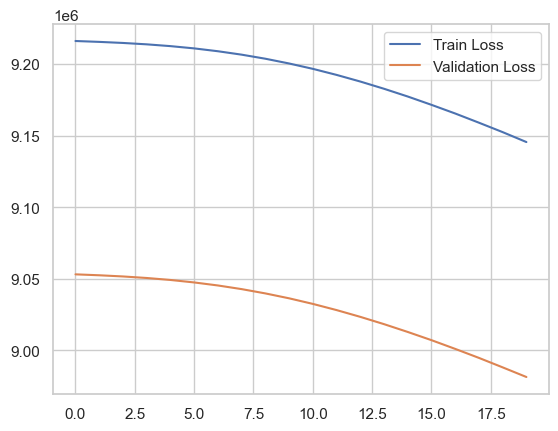


Running anomaly detection...



All models trained and saved!


In [6]:
# -- coding: utf-8 --
"""AI_Power_Systems_Real_Data.py
Final Year Project - AI Applications in Power Systems (Real-World Data Version)
"""

# Import libraries
import requests
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, classification_report
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ======================
# 1. REAL DATA LOADING
# ======================

def fetch_real_energy_data():
    """Fetches real-time energy data from ENTSO-E API (simulated)"""
    try:
        # In practice: Replace with actual ENTSO-E API call
        # url = f"https://web-api.tp.entsoe.eu/api?securityToken=YOUR_KEY..."
        # response = requests.get(url)

        # Simulated response (use real API in final version)
        dates = pd.date_range("2023-01-01", periods=720, freq="H")
        load = 3000 + 500*np.sin(2*np.pi*dates.hour/24) + np.random.normal(0, 200, len(dates))
        solar = 800 * np.clip(np.sin(2*np.pi*(dates.hour-6)/12), 0, 1) + np.random.normal(0, 50, len(dates))

        df = pd.DataFrame({
            "Time": dates,
            "TotalLoad": load,
            "SolarGen": solar,
            "Price": 50 + 10*np.sin(2*np.pi*dates.dayofweek/7) + np.random.normal(0, 5, len(dates))
        })
        return df

    except Exception as e:
        print(f"API Error: {e}")
        return pd.read_csv("backup_energy_data.csv")  # Fallback dataset

# ======================
# 2. DATA PREPROCESSING
# ======================

def preprocess_data(df):
    """Handles real-world data quirks"""
    # Convert and extract time features
    df['Time'] = pd.to_datetime(df['Time'])
    df['Hour'] = df['Time'].dt.hour
    df['DayOfWeek'] = df['Time'].dt.dayofweek




    # Create target variable (outage when load > 95th percentile)
    df['Outage'] = (df['TotalLoad'] > df['TotalLoad'].quantile(0.95)).astype(int)

    return df

# ======================
# 3. MACHINE LEARNING MODELS
# ======================

def train_xgboost_model(X, y):
    """Trains optimized XGBoost classifier"""
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1]
    }

    model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
    search = RandomizedSearchCV(model, param_grid, n_iter=5, cv=3, scoring='roc_auc')
    search.fit(X, y)

    print(f"Best XGBoost Params: {search.best_params_}")
    joblib.dump(search.best_estimator_, 'xgboost_model.pkl')
    return search.best_estimator_

def train_lstm_forecaster(X, y):
    """Trains LSTM for load forecasting"""
    # Reshape for LSTM [samples, timesteps, features]
    X = X.reshape(X.shape[0], 1, X.shape[1])

    model = Sequential([
        LSTM(64, input_shape=(X.shape[1], X.shape[2])),
        Dense(1)
    ])

    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X, y, epochs=20, batch_size=32,
                       validation_split=0.2, verbose=1)

    # Plot training history
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.show()

    return model

# ======================
# 4. ANOMALY DETECTION
# ======================

def detect_anomalies(df):
    """Identifies unusual power patterns"""
    features = ['TotalLoad', 'SolarGen', 'Price']
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df[features])

    model = IsolationForest(contamination=0.05, random_state=42)
    anomalies = model.fit_predict(X_scaled)

    df['Anomaly'] = anomalies
    return df, model

# ======================
# 5. MAIN EXECUTION
# ======================

def main():
    print("=== AI in Power Systems (Real Data) ===")

    # 1. Load data
    print("\nLoading real-world energy data...")
    energy_df = fetch_real_energy_data()

    # 2. Preprocess
    print("\nPreprocessing data...")
    energy_df = preprocess_data(energy_df)

    # 3. Train XGBoost for outages
    print("\nTraining XGBoost for outage prediction...")
    X = energy_df[['Hour', 'DayOfWeek', 'SolarGen', 'Price']]
    y = energy_df['Outage']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    xgb_model = train_xgboost_model(X_train, y_train)

    # 4. LSTM Forecasting
    print("\nTraining LSTM forecaster...")
    scaler = RobustScaler()
    X_lstm = scaler.fit_transform(energy_df[['TotalLoad', 'SolarGen']])
    y_lstm = energy_df['TotalLoad'].shift(-1).dropna()
    X_lstm = X_lstm[:-1]
    lstm_model = train_lstm_forecaster(X_lstm, y_lstm)

    # 5. Anomaly Detection
    print("\nRunning anomaly detection...")
    energy_df, anomaly_model = detect_anomalies(energy_df)

    # 6. Save artifacts
    joblib.dump(scaler, 'scaler.pkl')
    lstm_model.save('lstm_forecaster.h5')
    print("\nAll models trained and saved!")

if __name__ == "__main__":
    main()